# 권효중, Numpy 미니프로젝트, 소포모어 징크스

In [449]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from nba_api.stats.endpoints import commonallplayers, playercareerstats, playerawards,leaguedashplayerstats
from nba_api.stats.static import players
import koreanize_matplotlib

In [450]:
df1 = pd.read_csv('End of Season Teams.csv')

df1 = df1[df1['type']=='All-Rookie']
df1['season'] = df1['season'].astype(float)
df1 = df1[df1['season']<=2015]
df1 = df1.drop(columns=['lg','player_id','number_tm','position'])

df2 = pd.read_csv('Seasons_Stats.csv')
df2 = df2.rename(columns = {'Year':'season','Player':'player'})
df2 = pd.merge(df2,df1,how='outer',on=['season','player'])
df2 = df2.drop_duplicates(subset=['player','Age'])
df2 = df2.dropna(subset='PER')

# 2. 이름이 같아도 활동 기간이 8년 이상 차이 나면 다른 사람으로 간주하는 로직
# (NBA 역사상 이름이 같고 시대가 다른 선수를 완벽히 분리하기 위함)
df2['year_gap'] = df2.groupby('player')['season'].diff().fillna(0)
df2['person_id'] = (df2['year_gap'] >7).groupby(df2['player']).cumsum()

# 3. 각 선수(그룹)별 '최초 등장 시즌' 찾기
# 이름과 위에서 만든 person_id를 동시에 고려하여 그룹핑
df2['first_season'] = df2.groupby(['player', 'person_id'])['season'].transform('min').astype(int)

# 4. 최종 고유 식별자(player_unique) 생성
# 예: "George Johnson (1971)", "George Johnson (1978)" 처럼 구분됨
df2['player'] = df2['player'] + " (" + df2['first_season'].astype(str) + ")"

# (선택) 중간 계산용 컬럼 삭제
df2 = df2.drop(columns=['year_gap', 'first_season','Unnamed: 0','person_id'])

# rookie = df2[df2['type'] == 'All-Rookie']
# df2 = df2[df2['player'].isin(rookie['player'])]
df2


,season,player,Pos,Age,Tm,G,GS,MP,PER,TS%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,type
486,1952.0,Al Cervi* (1952),PG,34.0,SYR,55.0,NaN,850.0,21.9,0.536,...,NaN,NaN,87.0,148.0,NaN,NaN,NaN,176.0,417.0,NaN
488,1952.0,Alfred McGuire* (1952),PG,23.0,NYK,59.0,NaN,788.0,12.8,0.471,...,NaN,NaN,121.0,107.0,NaN,NaN,NaN,136.0,208.0,NaN
489,1952.0,Andy Phillip* (1952),SG,29.0,PHW,66.0,NaN,2933.0,15.9,0.440,...,NaN,NaN,434.0,539.0,NaN,NaN,NaN,218.0,790.0,NaN
490,1952.0,Arnie Johnson (1952),SF,31.0,ROC,66.0,NaN,2158.0,16.4,0.565,...,NaN,NaN,404.0,182.0,NaN,NaN,NaN,259.0,657.0,NaN
491,1952.0,Arnie Risen* (1952),C,27.0,ROC,66.0,NaN,2396.0,20.6,0.463,...,NaN,NaN,841.0,150.0,NaN,NaN,NaN,258.0,1032.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24732,2017.0,Wilson Chandler (2008),SF,29.0,DEN,71.0,33.0,2197.0,14.9,0.545,...,103.0,356.0,459.0,141.0,52.0,30.0,114.0,172.0,1117.0,NaN
24733,2017.0,Yogi Ferrell (2017),PG,23.0,TOT,46.0,29.0,1197.0,13.1,0.533,...,20.0,91.0,111.0,172.0,42.0,9.0,70.0,90.0,462.0,NaN
24736,2017.0,Zach LaVine (2015),SG,21.0,MIN,47.0,47.0,1749.0,14.6,0.576,...,18.0,141.0,159.0,139.0,41.0,10.0,85.0,104.0,889.0,NaN
24737,2017.0,Zach Randolph (2002),PF,35.0,MEM,73.0,5.0,1786.0,18.5,0.490,...,182.0,416.0,598.0,122.0,38.0,10.0,99.0,136.0,1028.0,NaN


### 데이터 병합 후 데뷔 시즌 후 연도 생성

In [ ]:
first_years = df2.groupby('player')['season'].min().rename('year_rookie')
first_age = df2.groupby('player')['Age'].min().rename('age_rookie')

# 기준 연도 데이터를 병합
df2 = df2.merge(first_years, on='player', how='left')
df2 = df2.merge(first_age, on='player', how='left')

# 기준 연도 이후 데이터만 필터링 (필요한 경우)
df_filtered = df2[(df2['season'] >= df2['year_rookie'])&(df2['Age'] >= df2['age_rookie'])].copy()

# 연도 변환: (현재 연도 - 기준 연도)를 수행하여 0, 1, 2... 생성
df_filtered['new_season'] = df_filtered['season'] - df_filtered['year_rookie']

df_all = df_filtered.drop(columns=['year_rookie','age_rookie']).reset_index(drop=True)
df_all = df_all.sort_values(by=['player','new_season'])
df_all.to_csv('result2.csv')


rookie = df_all[df_all['type'] == 'All-Rookie']
df = df_all[df_all['player'].isin(rookie['player'])]
df.to_csv('result.csv')

In [506]:
# 원본 컬럼명인 'PER', 'TS%', 'player' 등을 그대로 사용합니다.
rookie_df = df[df['new_season'] == 0.0].copy()
sophomore_df = df[df['new_season'] == 1.0].copy()

# 3. player를 기준으로 조인 (한 행에서 비교하기 위함)
# lsuffix(루키), rsuffix(소포모어)를 붙여 컬럼을 구분합니다.
analysis_df = rookie_df.merge(
    sophomore_df, 
    on='player', 
    how='inner', 
    suffixes=('_RK', '_SO')
)

# 4. 분석에 필요한 지표 계산
# PPG (경기당 득점)
analysis_df['PPG_RK'] = analysis_df['PTS_RK'] / analysis_df['G_RK']
analysis_df['PPG_SO'] = analysis_df['PTS_SO'] / analysis_df['G_SO']

# 주요 지표 변화량 (Delta)
analysis_df['delta_PPG'] = analysis_df['PPG_SO'] - analysis_df['PPG_RK']
analysis_df['delta_PER'] = analysis_df['PER_SO'] - analysis_df['PER_RK']
analysis_df['delta_TS%'] = (analysis_df['TS%_SO'] - analysis_df['TS%_RK']) * 100
analysis_df['delta_WS/48'] = analysis_df['WS/48_SO'] - analysis_df['WS/48_RK']
analysis_df['delta_USG%'] = analysis_df['USG%_SO'] - analysis_df['USG%_RK']

# 5. 슬럼프 지수(Slump Index) 계산
# 음수값이 클수록 징크스가 심한 것으로 해석
analysis_df['Slump_Index'] = (
    analysis_df['delta_PER'] * 1.0 + 
    analysis_df['delta_TS%'] * 0.5 + 
    analysis_df['delta_WS/48'] * 20.0
)

# 6. 결과 정렬 및 출력 (상위 10명)
# 'player_RK'는 조인 후 루키 쪽의 선수 이름 컬럼입니다.
ranking = analysis_df[[
    'player', 'PPG_RK', 'PPG_SO', 'delta_PPG', 
    'delta_PER', 'delta_TS%', 'delta_USG%', 'Slump_Index'
]].sort_values(by='delta_PER', ascending=True)

print("--- NBA 역대 가장 심한 소포모어 징크스 TOP 10 ---")
display(ranking.head(10))

--- NBA 역대 가장 심한 소포모어 징크스 TOP 10 ---


,player,PPG_RK,PPG_SO,delta_PPG,delta_PER,delta_TS%,delta_USG%,Slump_Index
52,Channing Frye (2006),12.338462,9.500000,-2.838462,-7.6,-7.7,-4.2,-13.13
131,J.R. Bremer (2003),8.250000,3.277778,-4.972222,-6.5,-16.1,1.7,-17.53
163,Jonny Flynn (2010),13.506173,5.264151,-8.242022,-5.9,-6.7,-5.7,-10.57
218,Marquis Daniels (2004),8.517857,9.083333,0.565476,-5.5,-5.2,0.0,-9.30
208,Marc Jackson (2001),13.187500,4.769231,-8.418269,-5.0,-6.7,-0.2,-8.95
320,Walt Williams (1993),16.966102,11.192982,-5.773119,-4.6,-5.7,-2.0,-8.87
48,Caron Butler (2003),15.397436,9.161765,-6.235671,-4.4,-6.2,-4.4,-8.22
116,Geoff Petrie (1971),24.768293,18.866667,-5.901626,-4.2,-3.8,NaN,-8.02
310,Tyreke Evans (2010),20.138889,17.754386,-2.384503,-3.8,-4.7,-0.9,-7.37
306,Travis Mays (1991),14.296875,8.500000,-5.796875,-3.7,4.5,2.1,-2.21


In [503]:
rookie_df = df[df['new_season'] == 0.0].copy()
sophomore_df = df[df['new_season'] == 1.0].copy()

analysis_df = rookie_df.merge(
    sophomore_df, 
    on='player', 
    how='inner', 
    suffixes=('_RK', '_SO')
)

# 2. 성장 지표 계산 (상승폭이 클수록 좋음)
analysis_df['delta_PER'] = analysis_df['PER_SO'] - analysis_df['PER_RK']
analysis_df['delta_WS/48'] = analysis_df['WS/48_SO'] - analysis_df['WS/48_RK']
analysis_df['delta_PTS_per_G'] = (analysis_df['PTS_SO']/analysis_df['G_SO']) - (analysis_df['PTS_RK']/analysis_df['G_RK'])

# 3. 성장 지수(Growth Index) 산출
# PER 상승에 가중치를 두어 계산
analysis_df['Growth_Index'] = (analysis_df['delta_PER'] * 1.0) + (analysis_df['delta_WS/48'] * 20.0)

# 4. 상위 10명 추출 (내림차순 정렬)
top_growers = analysis_df[[
    'player', 'PER_RK', 'PER_SO', 'delta_PER', 'delta_PTS_per_G', 'Growth_Index'
]].sort_values(by='Growth_Index', ascending=False).head(10)

print("=== NBA 역대 소포모어 성장 TOP 10 ===")
display(top_growers)

=== NBA 역대 소포모어 성장 TOP 10 ===


,player,PER_RK,PER_SO,delta_PER,delta_PTS_per_G,Growth_Index
195,LeBron James (2004),18.3,25.7,7.4,6.250791,9.90
81,DeMarcus Cousins (2011),14.6,21.7,7.1,4.013889,8.74
251,Rasheed Wallace (1996),11.8,18.4,6.6,5.052109,8.60
99,Dwyane Wade (2004),17.6,23.1,5.5,7.832020,6.98
179,Kevin Durant (2008),15.8,20.8,5.0,4.983784,6.84
300,Tim Hardaway (1990),16.0,20.9,4.9,8.230164,6.66
268,Rudy Gay (2007),12.4,17.4,5.0,9.301994,6.38
139,Jameer Nelson (2005),14.5,19.5,5.0,5.875255,6.16
304,Tony Parker (2002),11.7,16.5,4.8,6.319766,5.88
85,Deron Williams (2006),12.4,17.1,4.7,5.412500,5.86


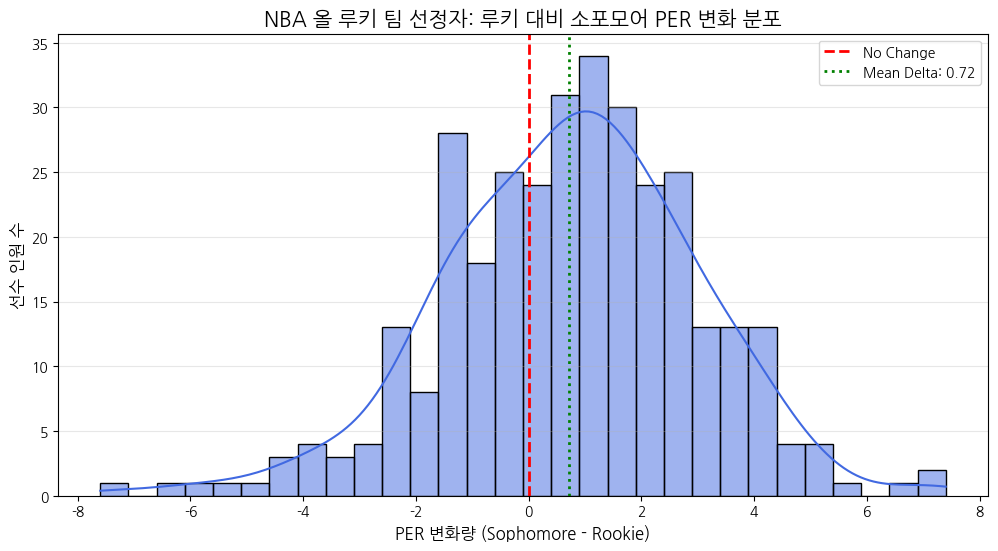

In [455]:
def plot_slump_distribution(df):
    plt.figure(figsize=(12, 6))
    
    # 1. PER 변화량 히스토그램
    sns.histplot(df['delta_PER'], kde=True, color='royalblue', bins=30)
    
    # 기준선 (변화 없음)
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
    
    # 평균 변화량 표시
    mean_delta = df['delta_PER'].mean()
    plt.axvline(mean_delta, color='green', linestyle=':', linewidth=2, label=f'Mean Delta: {mean_delta:.2f}')
    
    plt.title('NBA 올 루키 팀 선정자: 루키 대비 소포모어 PER 변화 분포', fontsize=15)
    plt.xlabel('PER 변화량 (Sophomore - Rookie)', fontsize=12)
    plt.ylabel('선수 인원 수', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_slump_distribution(analysis_df)

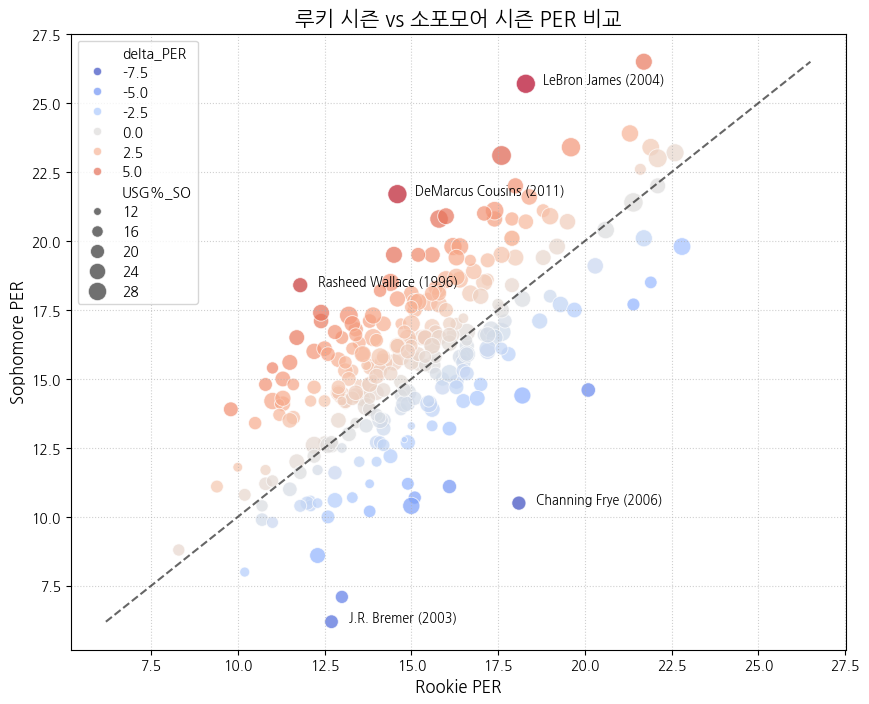

In [456]:
def plot_rookie_vs_sophomore(df):
    plt.figure(figsize=(10, 8))
    
    # 산점도 그리기 (점유율을 점의 크기로 표현하면 더 풍부해집니다)
    sns.scatterplot(data=df, x='PER_RK', y='PER_SO', 
                    size='USG%_SO', hue='delta_PER', palette='coolwarm', 
                    sizes=(20, 200), alpha=0.7)
    
    # y=x 기준선 (이 선 위에 있으면 성장, 아래에 있으면 징크스)
    max_val = max(df['PER_RK'].max(), df['PER_SO'].max())
    min_val = min(df['PER_RK'].min(), df['PER_SO'].min())
    plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', alpha=0.6)
    
    plt.title('루키 시즌 vs 소포모어 시즌 PER 비교', fontsize=15)
    plt.xlabel('Rookie PER', fontsize=12)
    plt.ylabel('Sophomore PER', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 주요 선수 텍스트 레이블 (예: 변화폭이 아주 큰 상위 5명)
    top_outliers = df.reindex(df['delta_PER'].abs().sort_values(ascending=False).index).head(5)
    for i, row in top_outliers.iterrows():
        plt.text(row['PER_RK']+0.5, row['PER_SO'], row['player'], fontsize=9)
        
    plt.show()

plot_rookie_vs_sophomore(analysis_df)

=== 시대별 소포모어 성적 변화 평균 ===
        delta_PER  delta_WS/48
decade                        
00s      0.665934     0.011077
10s      0.661062     0.014850
80s      0.841667     0.018139
90s      0.783333     0.007244


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\1655801626.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='decade', y='delta_PER', order=['80s', '90s', '00s', '10s'], palette='Set3')


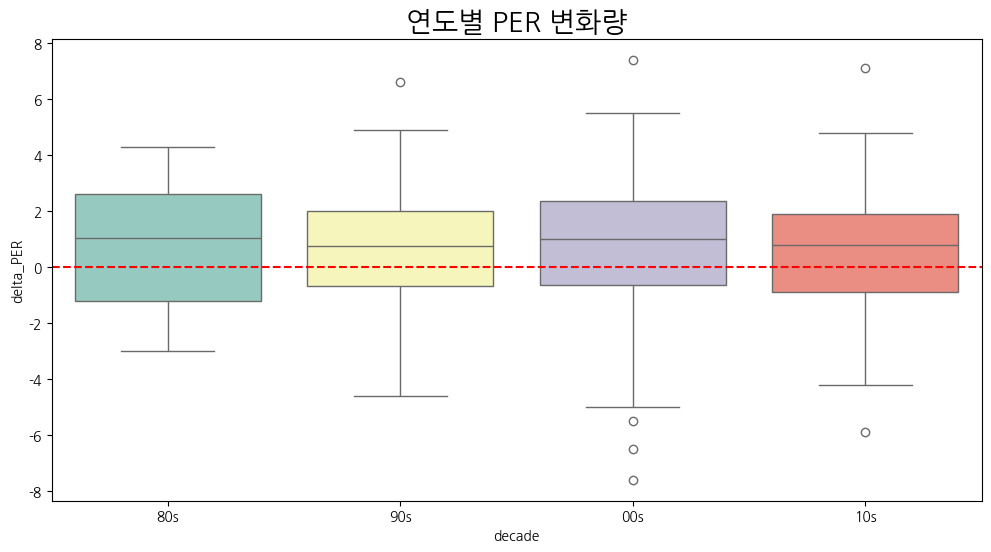

In [472]:
# 데이터 로드 및 전처리 (이전과 동일)
df = pd.read_csv('result.csv')

rookie_df = df[df['new_season'] == 0.0].copy()
sophomore_df = df[df['new_season'] == 1.0].copy()

analysis_df = rookie_df.merge(
    sophomore_df, on='player', how='inner', suffixes=('_RK', '_SO')
)


def assign_decade(season):
    # result.csv의 인덱스나 특정 컬럼이 연도와 비례한다고 가정할 때의 로직
    # 실제 연도 컬럼이 있다면 그 컬럼을 사용하세요.
    if 1980 <= season < 1990:
        return '80s'
    elif 1990 <= season < 2000:
        return '90s'
    elif 2000 <= season < 2010:
        return '00s'
    else:
        return '10s'

# 분석 편의상 데이터의 시대적 흐름을 반영하는 컬럼을 생성합니다.
analysis_df['decade'] = analysis_df['season_RK'].apply(assign_decade)

# 2. 시대별 주요 지표 변화량 계산
analysis_df['delta_PER'] = analysis_df['PER_SO'] - analysis_df['PER_RK']
analysis_df['delta_WS/48'] = analysis_df['WS/48_SO'] - analysis_df['WS/48_RK']

# 3. 시대별 평균 계산
decade_summary = analysis_df.groupby('decade')[['delta_PER', 'delta_WS/48']].mean()

print("=== 시대별 소포모어 성적 변화 평균 ===")
print(decade_summary)

# 4. 시각화 (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=analysis_df, x='decade', y='delta_PER', order=['80s', '90s', '00s', '10s'], palette='Set3')
plt.axhline(0, color='red', linestyle='--')
plt.title('연도별 PER 변화량',size=20)
plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3240424587.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Group_RK', y='delta_PER', palette='Set2')


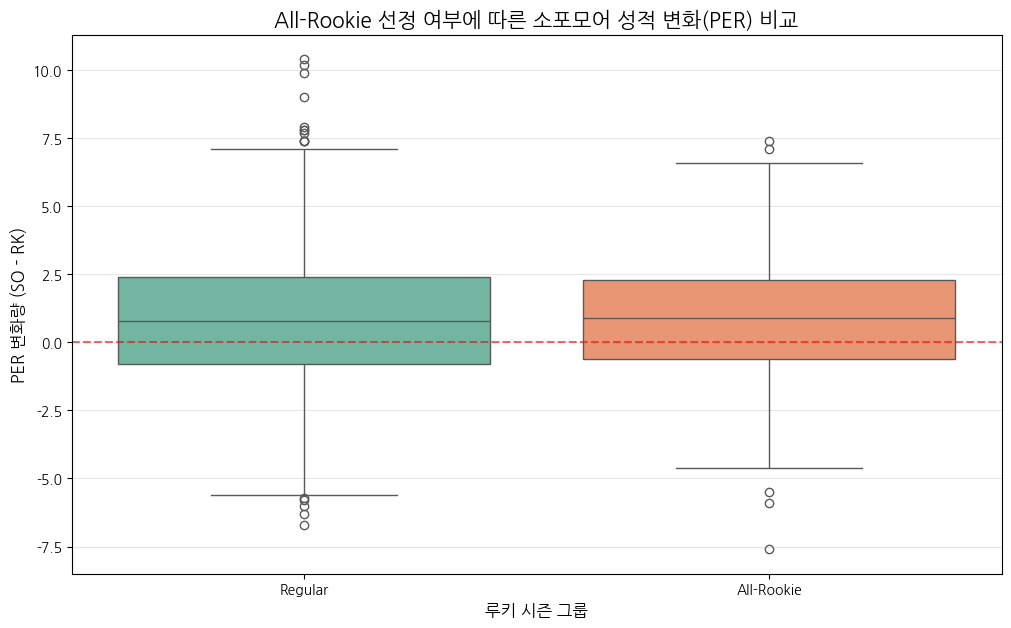

=== 그룹별 성적 변화 요약 ===
                mean  50%       std
Group_RK                           
All-Rookie  0.806231  0.9  2.176011
Regular     0.817121  0.8  2.539130


In [458]:
# 2. 루키와 소포모어 데이터 분리 (new_season 0.0=루키, 1.0=소포모어)

# 2. 전처리: 'All-Rookie' 팀 선정자 명단 추출
# type 컬럼에 'All-Rookie'가 한 번이라도 등장하는 선수 이름을 유니크하게 추출
all_rookie_players = df_all[df_all['type'] == 'All-Rookie']['player'].unique()

# 3. 전체 데이터에 Group 적용 (명단에 있으면 All-Rookie, 없으면 Regular)
df_all['Group'] = df_all['player'].apply(lambda x: 'All-Rookie' if x in all_rookie_players else 'Regular')


df_clean = df_all.sort_values('MP', ascending=False).drop_duplicates(subset=['player', 'new_season'])
df_clean = df_clean[df_clean['MP'] >= 500] 

# 4. 루키/소포모어 분리 및 조인
rookie_df = df_clean[df_clean['new_season'] == 0.0].copy()
sophomore_df = df_clean[df_clean['new_season'] == 1.0].copy()

# 3. 조인 (player 이름을 기준으로 루키-소포모어 쌍 구성)
analysis_df = rookie_df.merge(
    sophomore_df, on='player', how='inner', suffixes=('_RK', '_SO')
)

analysis_df = analysis_df.dropna(subset='PER_SO')
# 5. 지표 계산 (PER 변화량)
analysis_df['delta_PER'] = analysis_df['PER_SO'] - analysis_df['PER_RK']

# 6. 시각화 (Violin Plot + Box Plot)
plt.figure(figsize=(12, 7))

# 바이올린 플롯은 데이터의 분포 밀도를 보여주기에 적합합니다.
sns.boxplot(data=analysis_df, x='Group_RK', y='delta_PER', palette='Set2')

# 극단적인 값(±20 이상)을 방지하기 위한 최소 출전시간 필터링
# 보통 루키 시즌 400분 미만 선수는 PER 변동성이 너무 큽니다.
analysis_df = analysis_df[(analysis_df['MP_RK'] > 400) & (analysis_df['MP_SO'] > 400)]

# 기준선 (0점: 변화 없음)
plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='No Change')

plt.title('All-Rookie 선정 여부에 따른 소포모어 성적 변화(PER) 비교', fontsize=15)
plt.ylabel('PER 변화량 (SO - RK)', fontsize=12)
plt.xlabel('루키 시즌 그룹', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 7. 수치 요약 출력
summary = analysis_df.groupby('Group_RK')['delta_PER'].describe()[['mean', '50%', 'std']]
print("=== 그룹별 성적 변화 요약 ===")
print(summary)

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\47012570.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_df, x='Stat', y='Delta', palette='Set3', showfliers=False)


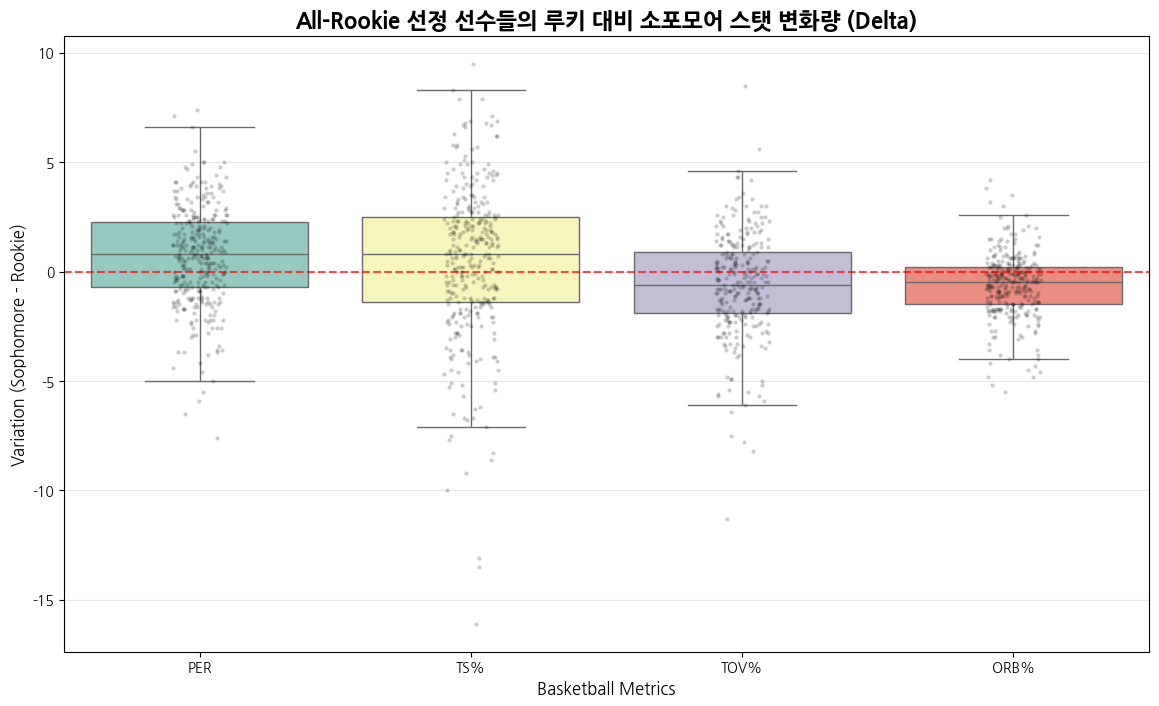

In [502]:

# 3. 루키(0.0)와 소포모어(1.0) 데이터 매칭
rookie_df = df[df['new_season'] == 0.0].copy()
sophomore_df = df[df['new_season'] == 1.0].copy()

# 'player' 이름을 기준으로 조인 (All-Rookie 전용 데이터이므로 그룹핑 생략)
analysis_df = rookie_df.merge(
    sophomore_df, on='player', how='inner', suffixes=('_RK', '_SO')
)

# 4. 5대 핵심 지표 변화량(Delta) 계산
# 변화량을 직관적으로 보기 위해 데이터프레임을 재구성(Melt)합니다.
analysis_df['PER'] = analysis_df['PER_SO'] - analysis_df['PER_RK']
analysis_df['TS%'] = (analysis_df['TS%_SO'] - analysis_df['TS%_RK']) * 100
analysis_df['TOV%'] = analysis_df['TOV%_SO'] - analysis_df['TOV%_RK']
analysis_df['ORB%'] = analysis_df['ORB%_SO'] - analysis_df['ORB%_RK']

# 시각화를 위해 스탯들을 하나로 모으기
metrics = ['PER', 'TS%', 'TOV%', 'ORB%']
melted_df = analysis_df.melt(id_vars=['player'], value_vars=metrics, var_name='Stat', value_name='Delta')

# 5. 시각화: 하나의 그래프에 5개 지표 표시
plt.figure(figsize=(14, 8))

# 박스플롯과 개별 선수의 분포(Stripplot)를 동시에 표시
sns.boxplot(data=melted_df, x='Stat', y='Delta', palette='Set3', showfliers=False)
sns.stripplot(data=melted_df, x='Stat', y='Delta', color='black', alpha=0.2, size=3, jitter=True)

# 0점 기준선 (성장과 하락의 경계)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title('All-Rookie 선정 선수들의 루키 대비 소포모어 스탯 변화량 (Delta)', fontsize=16, fontweight='bold')
plt.ylabel('Variation (Sophomore - Rookie)', fontsize=12)
plt.xlabel('Basketball Metrics', fontsize=12)
plt.grid(axis='y', alpha=0.3)



plt.show()

C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\2749821686.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['new_season'] <= 5], x='new_season', y='PER',
C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\2749821686.py:15: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  PER_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average PER')


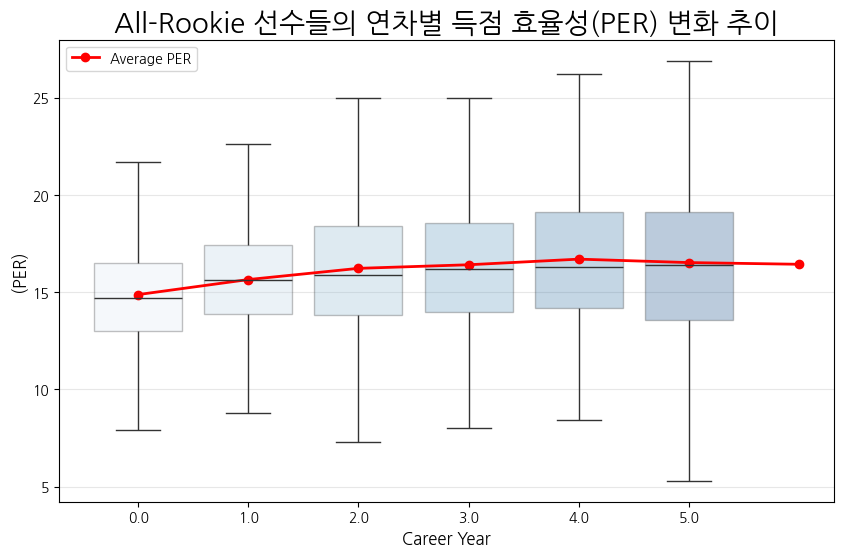

In [ ]:
# 데이터 신뢰도 확보 (너무 적게 뛴 시즌은 계산에서 제외)
df_clean = df[df['MP'] >= 400].copy()

# 2. 연차별 평균 계산 (요청하신 방식)
PER_mean = df_clean.groupby('new_season')['PER'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))

# 연차별 전체적인 분포를 Boxplot으로 표현 (배경)
sns.boxplot(data=df_clean[df_clean['new_season'] <= 5], x='new_season', y='PER', 
            palette='Blues', showfliers=False, boxprops=dict(alpha=0.3))

# 요청하신 평균 선 그래프 (강조)
PER_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average PER')

# 그래프 설정
plt.title('All-Rookie 선수들의 연차별 득점 효율성(PER) 변화 추이', fontsize=20)
plt.xlabel('Career Year', fontsize=12)
plt.ylabel('(PER)', fontsize=12)
plt.xticks(range(6))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3335896621.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['new_season'] <= 5], x='new_season', y='TS%',
C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3335896621.py:15: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  TS_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average TS%')


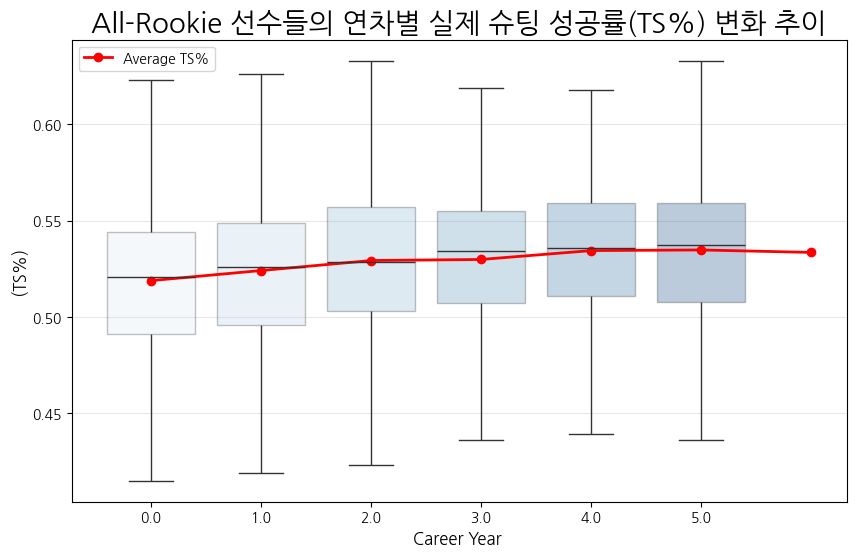

In [ ]:
# 데이터 신뢰도 확보 (너무 적게 뛴 시즌은 계산에서 제외)
df_clean = df[df['MP'] >= 400].copy()

# 2. 연차별 평균 계산 (요청하신 방식)
TS_mean = df_clean.groupby('new_season')['TS%'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))

# 연차별 전체적인 분포를 Boxplot으로 표현 (배경)
sns.boxplot(data=df_clean[df_clean['new_season'] <= 5], x='new_season', y='TS%', 
            palette='Blues', showfliers=False, boxprops=dict(alpha=0.3))

# 요청하신 평균 선 그래프 (강조)
TS_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average TS%')

# 그래프 설정
plt.title('All-Rookie 선수들의 연차별 실제 슈팅 성공률(TS%) 변화 추이', fontsize=20)
plt.xlabel('Career Year ', fontsize=12)
plt.ylabel('(TS%)', fontsize=12)
plt.xticks(range(6))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3688535728.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['new_season'] <= 5], x='new_season', y='WS/48',
C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3688535728.py:15: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  WS48_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average WS/48')


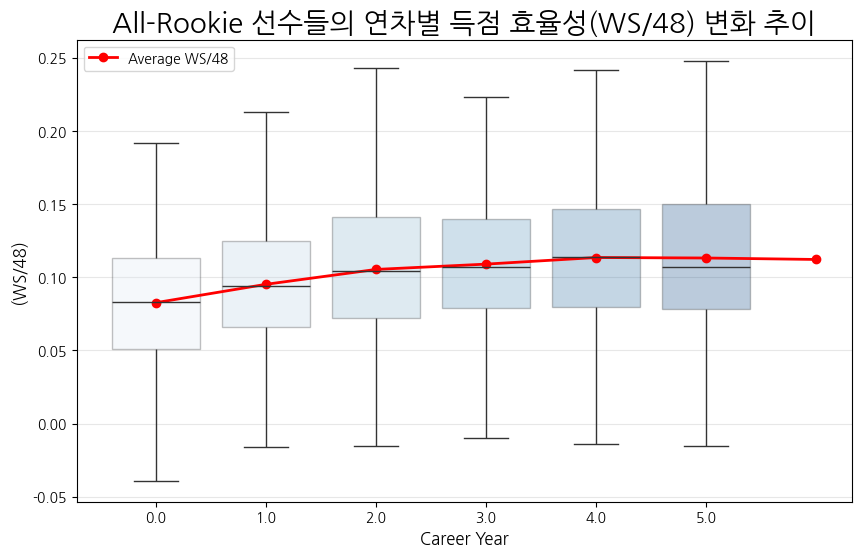

In [ ]:
# 데이터 신뢰도 확보 (너무 적게 뛴 시즌은 계산에서 제외)
df_clean = df[df['MP'] >= 400].copy()

# 2. 연차별 평균 계산 (요청하신 방식)
WS48_mean = df_clean.groupby('new_season')['WS/48'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))

# 연차별 전체적인 분포를 Boxplot으로 표현 (배경)
sns.boxplot(data=df_clean[df_clean['new_season'] <= 5], x='new_season', y='WS/48', 
            palette='Blues', showfliers=False, boxprops=dict(alpha=0.3))

# 요청하신 평균 선 그래프 (강조)
WS48_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average WS/48')

# 그래프 설정
plt.title('All-Rookie 선수들의 연차별 득점 효율성(WS/48) 변화 추이', fontsize=20)
plt.xlabel('Career Year', fontsize=12)
plt.ylabel('(WS/48)', fontsize=12)
plt.xticks(range(6))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()



C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\2018573844.py:12: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  USG_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average USG%')


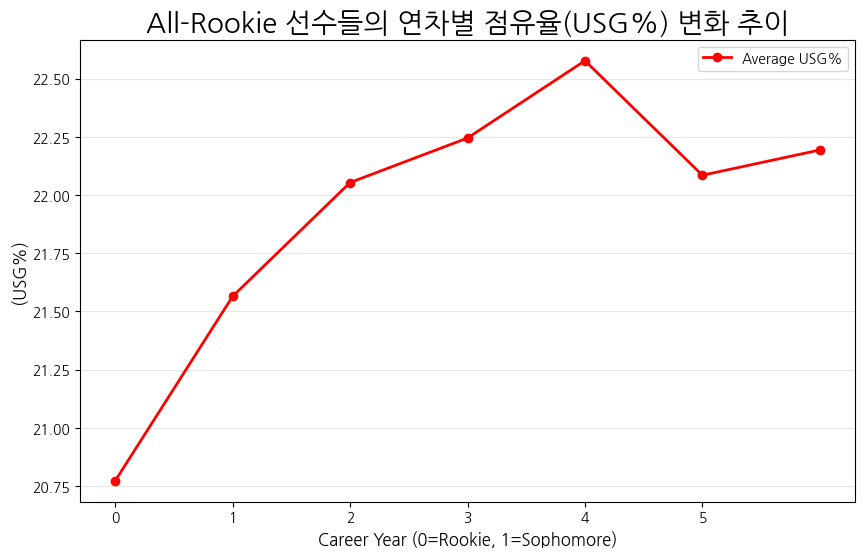

In [ ]:
# 데이터 신뢰도 확보 (너무 적게 뛴 시즌은 계산에서 제외)
df_clean = df[df['MP'] >= 400].copy()

# 2. 연차별 평균 계산 (요청하신 방식)
USG_mean = df_clean.groupby('new_season')['USG%'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))


# 요청하신 평균 선 그래프 (강조)
USG_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average USG%')

# 그래프 설정
plt.title('All-Rookie 선수들의 연차별 점유율(USG%) 변화 추이', fontsize=20)
plt.xlabel('Career Year (0=Rookie, 1=Sophomore)', fontsize=12)
plt.ylabel('(USG%)', fontsize=12)
plt.xticks(range(6))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3598086979.py:12: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  DBPM_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average DBPM')


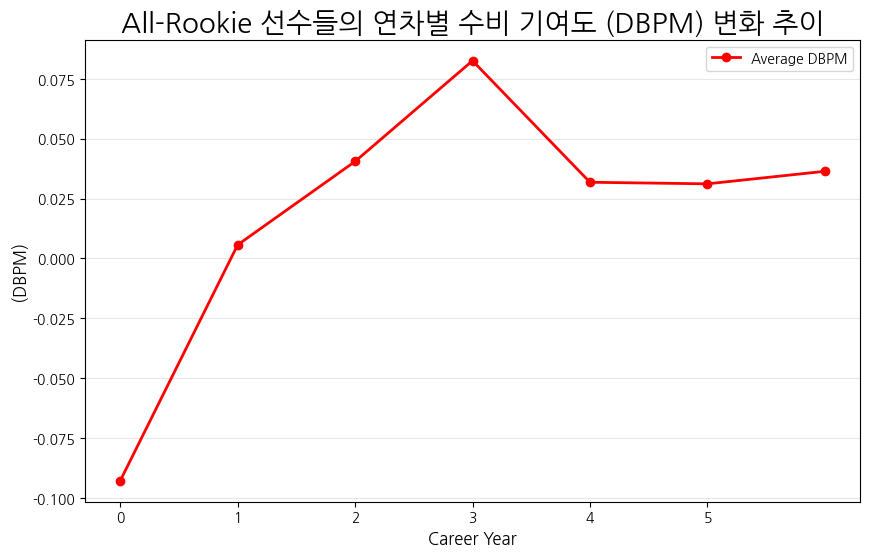

In [ ]:
# 데이터 신뢰도 확보 (너무 적게 뛴 시즌은 계산에서 제외)
df_clean = df[df['MP'] >= 400].copy()

# 2. 연차별 평균 계산 (요청하신 방식)
DBPM_mean = df_clean.groupby('new_season')['DBPM'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))


# 요청하신 평균 선 그래프 (강조)
DBPM_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average DBPM')

# 그래프 설정
plt.title('All-Rookie 선수들의 연차별 수비 기여도 (DBPM) 변화 추이', fontsize=20)
plt.xlabel('Career Year', fontsize=12)
plt.ylabel('(DBPM)', fontsize=12)
plt.xticks(range(6))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3413154912.py:12: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  tov_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average TOV')


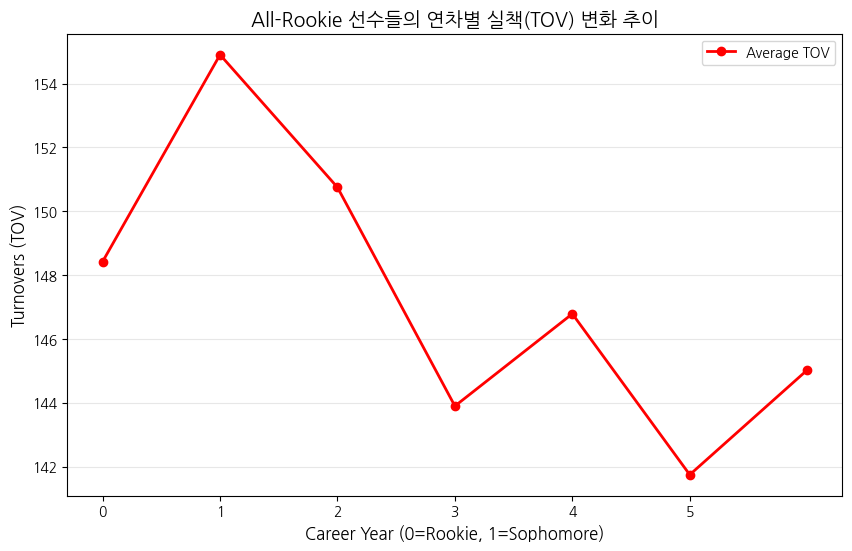

In [ ]:
# 데이터 신뢰도 확보 (너무 적게 뛴 시즌은 계산에서 제외)
df_clean = df[df['MP'] >= 400].copy()

# 2. 연차별 평균 계산 (요청하신 방식)
tov_mean = df_clean.groupby('new_season')['TOV'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))


# 요청하신 평균 선 그래프 (강조)
tov_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average TOV')

# 그래프 설정
plt.title('All-Rookie 선수들의 연차별 실책(TOV) 변화 추이', fontsize=14)
plt.xlabel('Career Year (0=Rookie, 1=Sophomore)', fontsize=12)
plt.ylabel('Turnovers (TOV)', fontsize=12)
plt.xticks(range(6))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


C:\Users\KDS12\AppData\Local\Temp\ipykernel_11724\3754450227.py:13: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  ORB_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average ORB%')


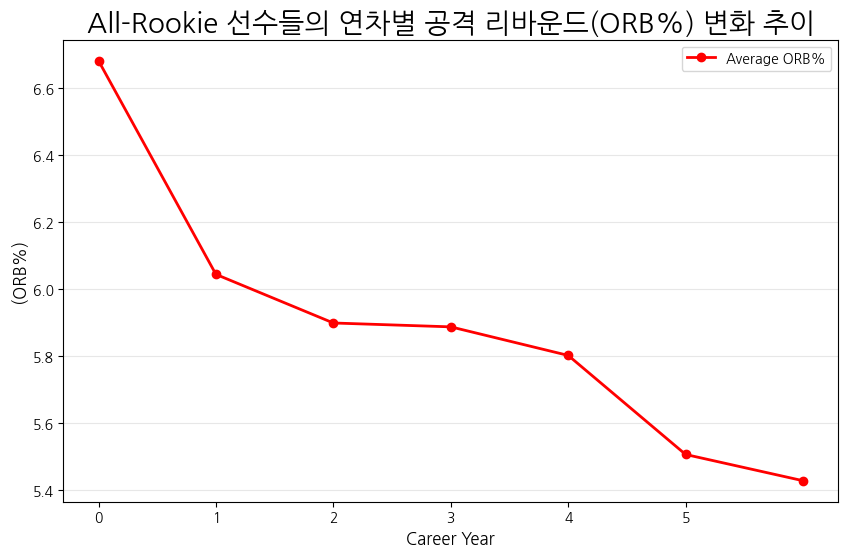

In [ ]:
# 데이터 신뢰도 확보 (너무 적게 뛴 시즌은 계산에서 제외)
df_clean = df[df['MP'] >= 400].copy()

# 2. 연차별 평균 계산 (요청하신 방식)
ORB_mean = df_clean.groupby('new_season')['ORB%'].mean()

# 3. 시각화
plt.figure(figsize=(10, 6))



# 요청하신 평균 선 그래프 (강조)
ORB_mean[:6].plot(kind='line', marker='o', color='red', linewidth=2, label='Average ORB%')

# 그래프 설정
plt.title('All-Rookie 선수들의 연차별 공격 리바운드(ORB%) 변화 추이', fontsize=20)
plt.xlabel('Career Year', fontsize=12)
plt.ylabel('(ORB%)', fontsize=12)
plt.xticks(range(6))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()
